In [2]:
!ls /kaggle/input/datasets/hanselliott/toxic-plant-classification/tpc-imgs/

full_metadata.csv  nontoxic_metadata.csv  toxic_images
nontoxic_images    README.txt		  toxic_metadata.csv


In [3]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [5]:
DATASET_PATH = "/kaggle/input/datasets/hanselliott/toxic-plant-classification/tpc-imgs/"

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [7]:
class ToxicPlantDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.samples = []

        toxic_dir = os.path.join(root_dir, "toxic_images")
        nontoxic_dir = os.path.join(root_dir, "nontoxic_images")

        for folder in os.listdir(toxic_dir):

            folder_path = os.path.join(toxic_dir, folder)

            if os.path.isdir(folder_path):

                for img in os.listdir(folder_path):

                    if img.lower().endswith(
                        (".jpg",".jpeg",".png",".bmp")
                    ):

                        self.samples.append(
                            (
                                os.path.join(folder_path, img),
                                1
                            )
                        )

        for folder in os.listdir(nontoxic_dir):

            folder_path = os.path.join(nontoxic_dir, folder)

            if os.path.isdir(folder_path):

                for img in os.listdir(folder_path):

                    if img.lower().endswith(
                        (".jpg",".jpeg",".png",".bmp")
                    ):

                        self.samples.append(
                            (
                                os.path.join(folder_path, img),
                                0
                            )
                        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
full_dataset = ToxicPlantDataset(
    DATASET_PATH,
    transform=train_transform
)

print("Total Images:", len(full_dataset))

Total Images: 9952


In [9]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 7961
Validation: 1991


In [10]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

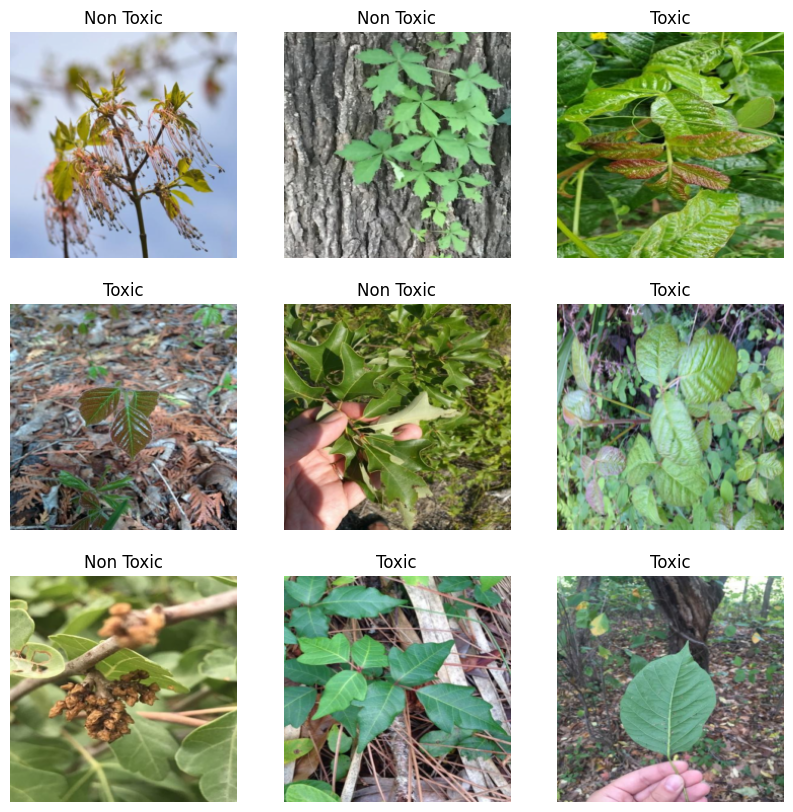

In [11]:
fig = plt.figure(figsize=(10,10))

for i in range(9):

    image, label = train_dataset[i]

    image = image.permute(1,2,0).numpy()

    image = image * np.array(
        [0.229,0.224,0.225]
    ) + np.array(
        [0.485,0.456,0.406]
    )

    image = np.clip(image,0,1)

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(
        "Toxic" if label==1
        else "Non Toxic"
    )

    plt.axis("off")

plt.show()

In [12]:
class ToxicPlantCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256,2)
        )

    def forward(self,x):

        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)

        return x

In [13]:
model = ToxicPlantCNN().to(device)
print(model)

ToxicPlantCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [14]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

In [15]:
def train_one_epoch():

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = outputs.max(1)

        total += labels.size(0)
        correct += preds.eq(labels).sum().item()

        acc = 100 * correct / total

        pbar.set_description(
            f"Loss:{loss.item():.4f} Acc:{acc:.2f}%"
        )

    return (
        running_loss/len(train_loader),
        100*correct/total
    )

In [16]:
def validate():

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            _, preds = outputs.max(1)

            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    return (
        running_loss/len(val_loader),
        100*correct/total
    )

In [18]:
epochs = 40

best_acc = 0
best_model = None

train_accs = []
val_accs = []

train_losses = []
val_losses = []

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train_one_epoch()

    val_loss, val_acc = validate()

    scheduler.step(val_acc)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        best_model = copy.deepcopy(
            model.state_dict()
        )

        print("Best Model Saved")

print(
    f"\nBest Validation Accuracy: "
    f"{best_acc:.2f}%"
)


Epoch 1/40


  0%|          | 0/249 [00:00<?, ?it/s]

Train Acc: 57.69% | Val Acc: 57.76%
Best Model Saved

Epoch 2/40


  0%|          | 0/249 [00:00<?, ?it/s]

Train Acc: 58.05% | Val Acc: 58.61%
Best Model Saved

Epoch 3/40


...

Train Acc: 73.17% | Val Acc: 62.68%

Epoch 39/40


  0%|          | 0/249 [00:00<?, ?it/s]

Train Acc: 74.29% | Val Acc: 65.29%

Epoch 40/40


  0%|          | 0/249 [00:00<?, ?it/s]

Train Acc: 76.12% | Val Acc: 64.69%

Best Validation Accuracy: 65.60%


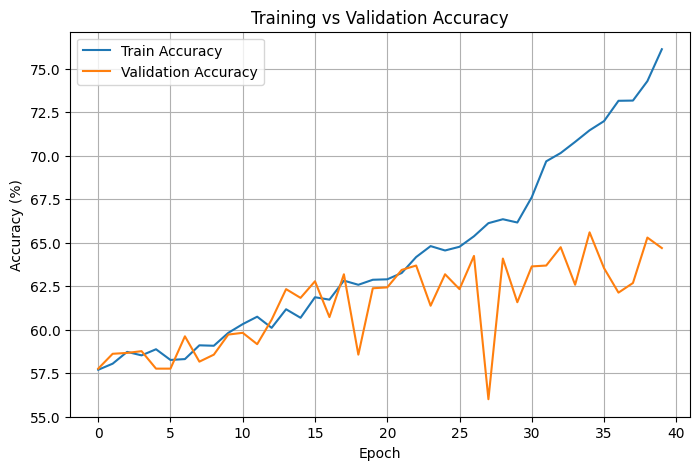

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    val_accs,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

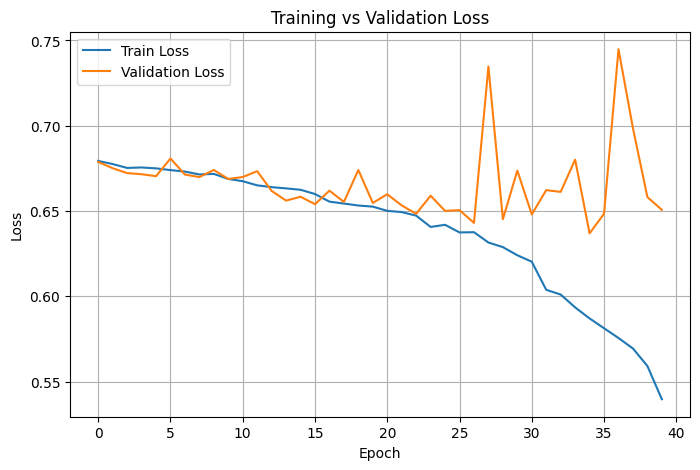

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

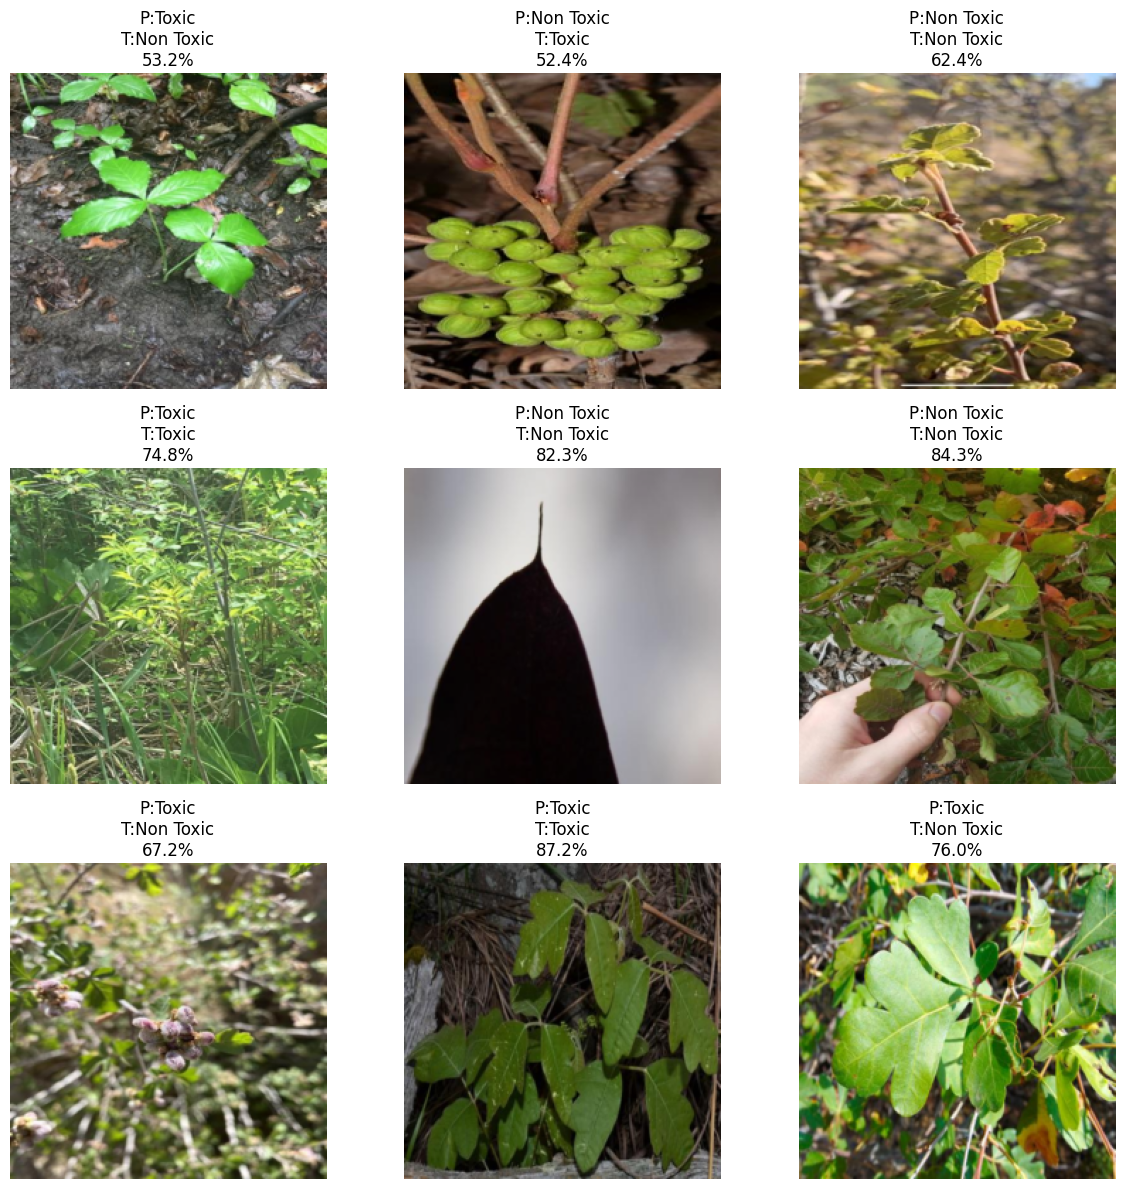

In [21]:
class_names = [
    "Non Toxic",
    "Toxic"
]

model.load_state_dict(best_model)
model.eval()

plt.figure(figsize=(12,12))

for i in range(9):

    idx = random.randint(
        0,
        len(val_dataset)-1
    )

    image, label = val_dataset[idx]

    inp = image.unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(inp)

        prob = torch.softmax(
            output,
            dim=1
        )

        conf, pred = torch.max(
            prob,
            1
        )

    img = image.permute(1,2,0).numpy()

    img = img * np.array(
        [0.229,0.224,0.225]
    ) + np.array(
        [0.485,0.456,0.406]
    )

    img = np.clip(img,0,1)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(
        f"P:{class_names[pred.item()]}\n"
        f"T:{class_names[label]}\n"
        f"{conf.item()*100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()